In [ ]:
import os # Added: Import the 'os' module at the beginning

In [ ]:
# 1.2 Verify GPU availability (optional but recommended):
print("--- Step 1.2: Verifying GPU Availability ---")
import torch
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"CUDA device name: {torch.cuda.get_device_name(0)}")
else:
    print("WARNING: CUDA is not available. Training will be very slow on CPU.")

--- Step 1.2: Verifying GPU Availability ---
CUDA available: True
CUDA device name: Tesla T4


In [ ]:
# 1.3 Mount Google Drive (Optional but Recommended for Persistence):
# While you want to upload a zip file, it's highly recommended to still mount Google Drive
# to save your trained model and results persistently, as direct uploads are temporary.
print("\n--- Step 1.3: Mounting Google Drive (Optional for Upload, Recommended for Saving) ---")
from google.colab import drive
try:
    drive.mount('/content/drive')
    print("Google Drive mounted successfully at /content/drive")
    # Set a base path for saving models/results to Google Drive
    google_drive_save_path = '/content/drive/My Drive/YOLOv8_Crack_Detection_Results/'
    os.makedirs(google_drive_save_path, exist_ok=True)
    print(f"Results will be saved to Google Drive at: {google_drive_save_path}")
except Exception as e:
    print(f"Error mounting Google Drive: {e}")
    print("Proceeding without Google Drive mount. Trained models/results will be temporary.")
    google_drive_save_path = './' # Save to current Colab session directory if Drive not mounted


--- Step 1.3: Mounting Google Drive (Optional for Upload, Recommended for Saving) ---
Mounted at /content/drive
Google Drive mounted successfully at /content/drive
Results will be saved to Google Drive at: /content/drive/My Drive/YOLOv8_Crack_Detection_Results/


In [ ]:
# --- Step 2: Upload and Unzip Your Dataset ---

# IMPORTANT: Files uploaded directly here are temporary and will be deleted when your Colab session ends.
# For persistent storage, use Google Drive (Step 1.3).

print("\n--- Step 2: Uploading and Unzipping Dataset ---")
from google.colab import files
import zipfile
import io
import os # Moved: Import the 'os' module here


--- Step 2: Uploading and Unzipping Dataset ---


In [ ]:
# Define the directory where the dataset will be unzipped in the Colab temporary file system
colab_dataset_base_path = '/content/welding_defect_dataset/' # Adjusted base path name for clarity
os.makedirs(colab_dataset_base_path, exist_ok=True)
print(f"Dataset will be unzipped to: {colab_dataset_base_path}")
print("\nPlease select your dataset ZIP file: 'Welding defect.v3-binov-defect-dataset.yolov8.zip'.")

Dataset will be unzipped to: /content/welding_defect_dataset/

Please select your dataset ZIP file: 'Welding defect.v3-binov-defect-dataset.yolov8.zip'.


In [ ]:
uploaded = files.upload()

Saving --.v1i.yolov8.zip to --.v1i.yolov8.zip


In [ ]:
for fn in uploaded.keys():
    print(f'User uploaded file "{fn}" ({len(uploaded[fn])} bytes)')
    # Unzip the uploaded file
    try:
        with zipfile.ZipFile(io.BytesIO(uploaded[fn]), 'r') as z:
            z.extractall(colab_dataset_base_path)
        print(f"Successfully unzipped {fn} to {colab_dataset_base_path}")

        # The previous 'NEW LOGIC' to handle single root folder is removed
        # because your specific zip structure has multiple top-level folders (train, test, valid).
        # We will directly use colab_dataset_base_path as the root for data.yaml's path.

    except zipfile.BadZipFile:
        print(f"Error: {fn} is not a valid zip file. Please ensure it's a correctly formatted ZIP archive.")
        # Exit or handle error appropriately if zip fails
    except Exception as e:
        print(f"An unexpected error occurred during unzipping: {e}")

User uploaded file "--.v1i.yolov8.zip" (193846067 bytes)
Successfully unzipped --.v1i.yolov8.zip to /content/welding_defect_dataset/


In [ ]:
# Check if the expected dataset structure exists after unzipping
# This check now looks for 'train/images' and 'valid/images' within the unzipped base path
expected_train_images_dir = os.path.join(colab_dataset_base_path, 'train', 'images')
expected_val_images_dir = os.path.join(colab_dataset_base_path, 'valid', 'images')

In [ ]:
if not os.path.exists(expected_train_images_dir) or not os.path.exists(expected_val_images_dir):
    print(f"WARNING: Expected structures (e.g., '{expected_train_images_dir}' and '{expected_val_images_dir}') not found.")
    print("Please ensure your zip file, when unzipped, places 'train', 'valid', and 'test' folders directly into the unzipped directory,")
    print("and that these folders contain 'images' and 'labels' subfolders.")
    print("Manually verify the contents of the unzipped directory in Colab's file browser (`/content/welding_defect_dataset/`).")
else:
    print(f"Dataset structure appears correct at: {colab_dataset_base_path}")


Dataset structure appears correct at: /content/welding_defect_dataset/


In [ ]:
# --- Step 3: Install Ultralytics (YOLOv8) ---

# Install the ultralytics library, which provides YOLOv8.
# The `-q` flag makes the installation quiet.
print("\n--- Step 3: Installing Ultralytics ---")
!pip install ultralytics -q
print("Ultralytics installed.")


--- Step 3: Installing Ultralytics ---
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 40.1 MB/s eta 0:00:00
Ultralytics installed.


In [ ]:
# Install PyTorch with CUDA support if not already present or for specific versions.
# Colab usually has PyTorch pre-installed with CUDA, but this is a safeguard.
# Replace 'cu118' with your specific CUDA version if necessary (e.g., cu117, cu121).
print("\n--- Step 3.1: Installing PyTorch with CUDA (if needed) ---")


--- Step 3.1: Installing PyTorch with CUDA (if needed) ---


In [ ]:
# Example for CUDA 11.8. Check Colab's CUDA version with !nvcc --version
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118 -q
print("PyTorch with CUDA support installed/verified.")

PyTorch with CUDA support installed/verified.


In [ ]:
# --- Step 4: Prepare Your Dataset (data.yaml) ---

# 4.1 Create data.yaml file:
# This file tells YOLOv8 about your dataset.
# The 'path' points to the unzipped dataset's base location.
# 'train', 'val', and 'test' paths are now relative to this base, and correspond to your zip content.
print("\n--- Step 4.1: Creating data.yaml file ---")


--- Step 4.1: Creating data.yaml file ---


In [ ]:
# The colab_dataset_base_path is now set to where the zip contents are directly unzipped.
data_yaml_content = f"""
# data.yaml for Colab direct upload (Welding Defect Dataset)

# Path to your dataset root in Colab's temporary storage
path: {colab_dataset_base_path}

# Train, validation, and test image paths relative to 'path'
train: train/images
val: valid/images # Using 'valid' as per your dataset structure
test: test/images # Including test set path

# Number of classes and Class names - VERIFY THESE WITH YOUR DATASET'S ORIGINAL data.yaml
# Your 'Welding defect.v3-binov-defect-dataset.yolov8.zip' might already contain a data.yaml
# with the correct class count and names. If so, you can directly use that.
# If not, or if you want to explicitly define them, update below:
nc: 1 # Example: Assuming 1 class for 'defect'. Update this!
names: ['defect'] # Example: Update with your actual class names from your dataset's data.yaml!
"""

# Define the full path for the data.yaml file (can be placed directly in the unzipped dataset root)
data_yaml_path = os.path.join(colab_dataset_base_path, 'data.yaml')

In [ ]:
# Check if a data.yaml already exists from the uploaded zip, and use it if preferred
# You can uncomment and modify this block if you want to prioritize the data.yaml from your zip
# if os.path.exists(os.path.join(colab_dataset_base_path, 'data.yaml')):
#     print(f"Found data.yaml in uploaded dataset: {os.path.join(colab_dataset_base_path, 'data.yaml')}")
#     data_yaml_path = os.path.join(colab_dataset_base_path, 'data.yaml')
#     print("Using the data.yaml provided in your zip file.")
# else:
#     with open(data_yaml_path, 'w') as f:
#         f.write(data_yaml_content)
#     print(f"Generated data.yaml at: {data_yaml_path}")
#     print("Content of generated data.yaml:")
#     print(data_yaml_content)

# For now, we will always generate the data.yaml with the corrected paths,
# overriding any data.yaml that might be in the zip to ensure path correctness.
with open(data_yaml_path, 'w') as f:
    f.write(data_yaml_content)
print(f"data.yaml created at: {data_yaml_path}")
print("Content of data.yaml:")
print(data_yaml_content)

data.yaml created at: /content/welding_defect_dataset/data.yaml
Content of data.yaml:

# data.yaml for Colab direct upload (Welding Defect Dataset)

# Path to your dataset root in Colab's temporary storage
path: /content/welding_defect_dataset/

# Train, validation, and test image paths relative to 'path'
train: train/images
val: valid/images # Using 'valid' as per your dataset structure
test: test/images # Including test set path

# Number of classes and Class names - VERIFY THESE WITH YOUR DATASET'S ORIGINAL data.yaml
# Your 'Welding defect.v3-binov-defect-dataset.yolov8.zip' might already contain a data.yaml
# with the correct class count and names. If so, you can directly use that.
# If not, or if you want to explicitly define them, update below:
nc: 1 # Example: Assuming 1 class for 'defect'. Update this!
names: ['defect'] # Example: Update with your actual class names from your dataset's data.yaml!



In [ ]:
# --- Step 5: Train Your YOLOv8 Model ---
# IMPORTANT: Ensure the cell containing 'from ultralytics import YOLO' and
# 'model = YOLO('yolov8n.pt')' has been executed before running model.train().
# Also, ensure Step 4.1, which defines 'data_yaml_path', has been run.

# Load the YOLO model
from ultralytics import YOLO
import os

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [ ]:
# Initialize a YOLO model with pre-trained weights (e.g., yolov8n.pt for nano version)
# You can choose yolov8s.pt, yolov8m.pt, yolov8l.pt, or yolov8x.pt for different sizes.
model = YOLO('yolov8s.pt')

In [ ]:
# Train the model
print("\n--- Step 5: Starting YOLOv8 Model Training ---")
# Adjust parameters like epochs, imgsz (image size), and batch size as needed.
# 'data' points to your data.yaml file located in the unzipped dataset.
# 'project' and 'name' help organize your training runs. We'll use the Google Drive path if mounted.
results = model.train(
    data=data_yaml_path,
    epochs=100,  # Number of training epochs. Adjust based on dataset size and desired accuracy.
    imgsz=640,   # Input image size.
    batch=16,    # Batch size. Adjust based on GPU memory. Lower if you get OOM errors.
         # stop if no val improvement for 20 epochs
    cos_lr=True,       # smoother convergence
    close_mosaic=10,   # fine-tune on real images at the end
    name='welding_defect_detection_model',  # Adjusted name for clarity
    project=os.path.join(google_drive_save_path, 'runs/detect')  # Save runs to Google Drive or local if not mounted
)



--- Step 5: Starting YOLOv8 Model Training ---
Ultralytics 8.3.192 🚀 Python-3.12.11 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/content/welding_defect_dataset/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=welding_defect_detection_model5, nbs=64, nms=False, opset=None, optimize=False, optimizer=au

In [ ]:
print("\nTraining complete! Results are saved in:")
print(f"{os.path.join(google_drive_save_path, 'runs/detect', 'welding_defect_detection_model')}/")
print("The best model weights are typically located at:")
print(f"{os.path.join(google_drive_save_path, 'runs/detect', 'welding_defect_detection_model', 'weights', 'best.pt')}")


Training complete! Results are saved in:
/content/drive/My Drive/YOLOv8_Crack_Detection_Results/runs/detect/welding_defect_detection_model/
The best model weights are typically located at:
/content/drive/My Drive/YOLOv8_Crack_Detection_Results/runs/detect/welding_defect_detection_model/weights/best.pt


In [ ]:

# --- Step 6: Perform Crack Detection (Inference) ---

# Construct the path to the best trained model using the actual save directory
# from the 'results' object of the completed training run.
trained_model_path = os.path.join(results.save_dir, 'weights', 'best.pt')

In [ ]:
print("\n--- Step 6: Performing Crack Detection (Inference) ---")


--- Step 6: Performing Crack Detection (Inference) ---


In [ ]:
# Check if the trained model actually exists
if not os.path.exists(trained_model_path):
    print(f"ERROR: Trained model not found at {trained_model_path}")
    print("This indicates an issue during training or saving the model.")
    print("Please verify the output of Step 5 for any errors or unexpected behaviors.")
    print(f"Expected model path: {trained_model_path}")
    print("Skipping inference as the model file is missing.")
else:
    print(f"Trained model found and loading from: {trained_model_path}")
    # Load the best trained model
    model = YOLO(trained_model_path)

Trained model found and loading from: /content/drive/My Drive/YOLOv8_Crack_Detection_Results/runs/detect/welding_defect_detection_model5/weights/best.pt


In [ ]:
# Check if the trained model actually exists
if not os.path.exists(trained_model_path):
    print(f"ERROR: Trained model not found at {trained_model_path}")
    print("This indicates an issue during training or saving the model.")
    print("Please verify the output of Step 5 for any errors or unexpected behaviors.")
    print(f"Expected model path: {trained_model_path}")
    print("Skipping inference as the model file is missing.")
else:
    print(f"Trained model found and loading from: {trained_model_path}")
    # Load the best trained model
    model = YOLO(trained_model_path)

    # 6.1 Detect on a single image:
    print("\n--- Step 6.1: Performing Inference on an Image ---")
    # For inference, you can either upload a new image directly or use one from Google Drive.
    # Here's how to upload a new image directly for testing:
    print("\nPlease select a new image file for inference (e.g., 'test_image.jpg').")
    test_image_upload = files.upload()
    test_image_name = list(test_image_upload.keys())[0] if test_image_upload else None
    test_image_path_colab = os.path.join('/content/', test_image_name) if test_image_name else None

    if test_image_path_colab and os.path.exists(test_image_path_colab):
        results_image = model.predict(
            source=test_image_path_colab,
            conf=0.25, # Confidence threshold for detection
            save=True, # Save results to disk
            name='image_inference_results', # Name for inference run
            project=os.path.join(google_drive_save_path, 'runs/predict') # Save predictions
        )
        print(f"Image inference complete. Results saved in: {os.path.join(google_drive_save_path, 'runs/predict', 'image_inference_results')}/")
    else:
        print("Warning: No test image uploaded or found. Skipping image inference.")

Trained model found and loading from: /content/drive/My Drive/YOLOv8_Crack_Detection_Results/runs/detect/welding_defect_detection_model5/weights/best.pt

--- Step 6.1: Performing Inference on an Image ---

Please select a new image file for inference (e.g., 'test_image.jpg').


Saving download (6).jpg to download (6).jpg
Saving download (5).jpg to download (5).jpg

image 1/1 /content/download (6).jpg: 384x640 8 defects, 48.8ms
Speed: 1.5ms preprocess, 48.8ms inference, 1.5ms postprocess per image at shape (1, 3, 384, 640)
Results saved to /content/drive/My Drive/YOLOv8_Crack_Detection_Results/runs/predict/image_inference_results2
Image inference complete. Results saved in: /content/drive/My Drive/YOLOv8_Crack_Detection_Results/runs/predict/image_inference_results/


In [ ]:
# 6.2 Detect on a video:
print("\n--- Step 6.2: Performing Inference on a Video ---")
# Similar to images, you can upload a test video directly or use one from Google Drive.
print("\nPlease select a new video file for inference (e.g., 'test_video.mp4').")
test_video_upload = files.upload()
test_video_name = list(test_video_upload.keys())[0] if test_video_upload else None
test_video_path_colab = os.path.join('/content/', test_video_name) if test_video_name else None

if test_video_path_colab and os.path.exists(test_video_path_colab):
    results_video = model.predict(
        source=test_video_path_colab,
        conf=0.25,
        save=True,
        name='video_inference_results',
        project=os.path.join(google_drive_save_path, 'runs/predict')
    )
    print(f"Video inference complete. Results saved in: {os.path.join(google_drive_save_path, 'runs/predict', 'video_inference_results')}/")
else:
    print("Warning: No test video uploaded or found. Skipping video inference.")



--- Step 6.2: Performing Inference on a Video ---

Please select a new video file for inference (e.g., 'test_video.mp4').


Saving WhatsApp Video 2025-09-03 at 9.57.05 AM.mp4 to WhatsApp Video 2025-09-03 at 9.57.05 AM.mp4

WARNING ⚠️ 
inference results will accumulate in RAM unless `stream=True` is passed, causing potential out-of-memory
errors for large sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict/ for help.

Example:
    results = model(source=..., stream=True)  # generator of Results objects
    for r in results:
        boxes = r.boxes  # Boxes object for bbox outputs
        masks = r.masks  # Masks object for segment masks outputs
        probs = r.probs  # Class probabilities for classification outputs

video 1/1 (frame 1/345) /content/WhatsApp Video 2025-09-03 at 9.57.05 AM.mp4: 640x384 3 defects, 93.5ms
video 1/1 (frame 2/345) /content/WhatsApp Video 2025-09-03 at 9.57.05 AM.mp4: 640x384 3 defects, 11.1ms
video 1/1 (frame 3/345) /content/WhatsApp Video 2025-09-03 at 9.57.05 AM.mp4: 640x384 3 defects, 10.6ms
video 1/1 (frame 4/345) /content/WhatsApp Vide

In [ ]:
# 6.3 Real-time detection from Webcam (Colab limitations):
print("\n--- Step 6.3: Real-time Detection from Webcam (Colab Notes) ---")
print("Direct webcam access for real-time inference in Google Colab notebooks is often tricky due to browser security and Colab's architecture.")
print("While 'source=0' is the command for local webcam, it usually won't work directly in Colab.")
print("For real-time applications, you typically need to run the script locally or use specialized Colab features (e.g., ngrok tunnels, or specific libraries that manage camera streams).")
print("Therefore, the command `!yolo detect predict model=... source=0` is generally for local environments, not direct Colab notebook use.")


--- Step 6.3: Real-time Detection from Webcam (Colab Notes) ---
Direct webcam access for real-time inference in Google Colab notebooks is often tricky due to browser security and Colab's architecture.
While 'source=0' is the command for local webcam, it usually won't work directly in Colab.
For real-time applications, you typically need to run the script locally or use specialized Colab features (e.g., ngrok tunnels, or specific libraries that manage camera streams).
Therefore, the command `!yolo detect predict model=... source=0` is generally for local environments, not direct Colab notebook use.



--- Step 6.4: Viewing Inference Results ---
Falling back to default inference path: /content/drive/My Drive/YOLOv8_Crack_Detection_Results/runs/predict/image_inference_results. Ensure Step 6.1 was successful.
Found 1 inference images. Displaying up to the first 5:
Displaying: /content/drive/My Drive/YOLOv8_Crack_Detection_Results/runs/predict/image_inference_results/23.jpg


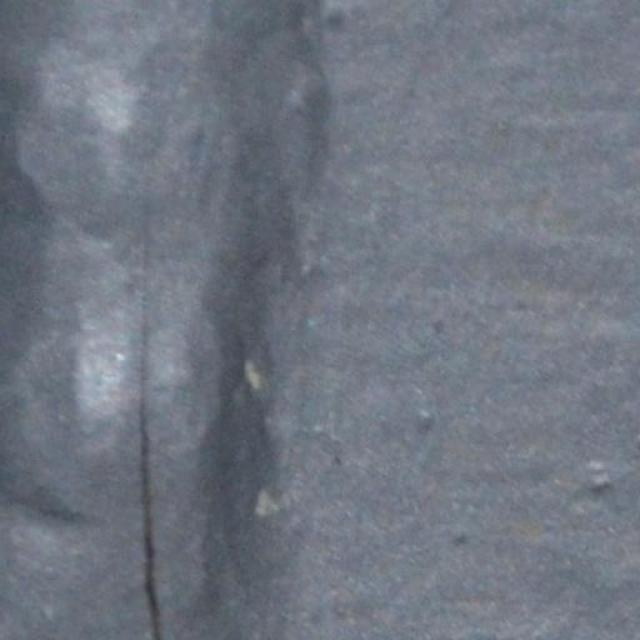

In [ ]:
# 6.4 View Inference Results:
print("\n--- Step 6.4: Viewing Inference Results ---")

import glob
import os
from IPython.display import Image, display

# Path where image inference results are saved.
# We now dynamically get this from the 'image_inference_results_obj' if it exists.
inference_image_save_dir = None
if 'image_inference_results_obj' in locals() and image_inference_results_obj and len(image_inference_results_obj) > 0:
    inference_image_save_dir = image_inference_results_obj[0].save_dir
else:
    # Fallback if image_inference_results_obj was not created or is empty
    inference_image_save_dir = os.path.join(google_drive_save_path, 'runs/predict/image_inference_results')
    print(f"Falling back to default inference path: {inference_image_save_dir}. Ensure Step 6.1 was successful.")

if inference_image_save_dir and os.path.exists(inference_image_save_dir):
    # Find all image files (e.g., .jpg, .png) in the inference results directory
    image_paths = glob.glob(os.path.join(inference_image_save_dir, '*.jpg')) + \
                  glob.glob(os.path.join(inference_image_save_dir, '*.png'))

    if not image_paths:
        print(f"No inference images (jpg/png) found inside: {inference_image_save_dir}")
        print("This can happen if no objects were detected or if the images were not saved.")
    else:
        print(f"Found {len(image_paths)} inference images. Displaying up to the first 5:")
        for i, img_path in enumerate(image_paths[:5]):  # Display up to 5 images
            print(f"Displaying: {img_path}")
            try:
                display(Image(filename=img_path))
            except Exception as e:
                print(f"Could not display image {img_path}: {e}")
            if i < len(image_paths[:5]) - 1:
                print("-" * 30)  # Separator for multiple images
else:
    print(f"Inference results directory does not exist or is not set: {inference_image_save_dir}")
    print("Please ensure Step 6.1 (Detect on a single image) was executed successfully and produced results.")
